In [3]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import IncrementalPCA
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import cv2
import joblib
import matplotlib.pyplot as plt
import time
from einops import rearrange
from IPython.display import clear_output
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])
from useful_stuff.general_utils.utils import print_wise, is_empty, get_device
from useful_stuff.image_processing.utils import get_video_dimensions, read_video
from useful_stuff.image_processing.computational_models import get_relevant_output_layers, load_model, pool_features, imgANN
# from image_processing.utils import concatenate_frames_batch, shuffle_frames
from image_processing.gaze_dep_models import extract_center_patches, sample_random_patches, capture_1917_movie_runs, extract_features_1917_movie,  save_ipca_patch, preprocess_batch, ipca_movie_patches


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
from dataclasses import dataclass, field
@dataclass
class Cfg:
    sq_size = 384
    input_size = 384
    secs_to_skip = 5
    batch_size = 5
    patches_per_frame = 3
    frames_step = 3 # every how many frames we want to take a sample (due to high temporal autocorrelation we can skip)
    patches_overhead_sampling = 2 # how many patches we want more than the images we're gonna pass to the model (to avoid proper shuffling)
    tot_patches = 3
    n_components = 2
    model_name = 'dino_v3_l'
    model_url = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    pkg = 'hf'
    pooling = "all"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, 'torchvision')
print(layers)

['layer.0.mlp.down_proj', 'layer.1.mlp.down_proj', 'layer.2.mlp.down_proj', 'layer.3.mlp.down_proj', 'layer.4.mlp.down_proj', 'layer.5.mlp.down_proj', 'layer.6.mlp.down_proj', 'layer.7.mlp.down_proj', 'layer.8.mlp.down_proj', 'layer.9.mlp.down_proj', 'layer.10.mlp.down_proj', 'layer.11.mlp.down_proj', 'layer.12.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.14.mlp.down_proj', 'layer.15.mlp.down_proj', 'layer.16.mlp.down_proj', 'layer.17.mlp.down_proj', 'layer.18.mlp.down_proj', 'layer.19.mlp.down_proj', 'layer.20.mlp.down_proj', 'layer.21.mlp.down_proj', 'layer.22.mlp.down_proj', 'layer.23.mlp.down_proj']


# backbone
1. capture the three vids
2. randomly select the moment in the movie for each of the three parts
3. read the frames (decide how many)
4. For each of the frame select the center patches and a random subset of patches (always considering the center but without overlap - maybe since H=522 we'll have a bit of overlap) 
5. shuffle with previous storage and extract features



In [7]:
m = imgANN(cfg.model_name, cfg.pkg,  cfg.input_size, dtype=torch.float16, attn_implementation='sdpa', repo_url=cfg.model_url)
ipca_movie_patches(paths, 0, layers[0], m, cfg.n_components, cfg.batch_size, cfg.patches_per_frame, cfg.frames_step, cfg.patches_overhead_sampling, cfg.sq_size, secs_to_skip=5)

13:06:15 - device being used: mps
13:06:20 - rank 0 processed batch 0 of 12573 features shape = torch.Size([5, 594944])
13:06:21 - rank 0 processed batch 1 of 12573 features shape = torch.Size([5, 594944])
13:06:23 - rank 0 processed batch 2 of 12573 features shape = torch.Size([5, 594944])
13:06:24 - rank 0 processed batch 3 of 12573 features shape = torch.Size([5, 594944])
13:06:26 - rank 0 processed batch 4 of 12573 features shape = torch.Size([5, 594944])
13:06:27 - rank 0 processed batch 5 of 12573 features shape = torch.Size([5, 594944])
13:06:28 - rank 0 processed batch 6 of 12573 features shape = torch.Size([5, 594944])
13:06:30 - rank 0 processed batch 7 of 12573 features shape = torch.Size([5, 594944])
13:06:31 - rank 0 processed batch 8 of 12573 features shape = torch.Size([5, 594944])
13:06:33 - rank 0 processed batch 9 of 12573 features shape = torch.Size([5, 594944])
13:06:34 - rank 0 processed batch 10 of 12573 features shape = torch.Size([5, 594944])
13:06:35 - rank 0 p

KeyboardInterrupt: 

In [30]:
fn = save_ipca_patch(paths, cfg.model_name, layers[0], cfg.n_components, cfg.sq_size, cfg.pooling)
print(fn)
ipca_obj = joblib.load(fn)


/Users/tizianocausin/1917_local/models/alexnet_features.0_8components_384x384patch_allpool.pkl


In [37]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
ANN.create_forward_hook([layers[0],])
torch.cuda.empty_cache()
caps_list = capture_1917_movie_runs(paths)
fps = caps_list[0].get(cv2.CAP_PROP_FPS)
tot_frames = []
for start_f in [3000,]:
    start_s = start_f/fps
    for cap in caps_list:
        end_f = start_f+300
        end_s = end_f/fps
        v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
        v = v[::cfg.frames_step]
        v = extract_center_patches(v, cfg.sq_size)
        if tot_frames is None:
            tot_frames = v
        else:
            tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
        # end if tot_frames is None:
    chunk = sample_random_patches(tot_frames, 100)
chunk_preprocessed = preprocess_batch(chunk, ANN.img_size, device=device)
ANN.model(chunk_preprocessed)
chunk_mod = ANN.features[layers[0]].cpu().detach().numpy()

pts = chunk_mod @ipca_obj.components_.T 


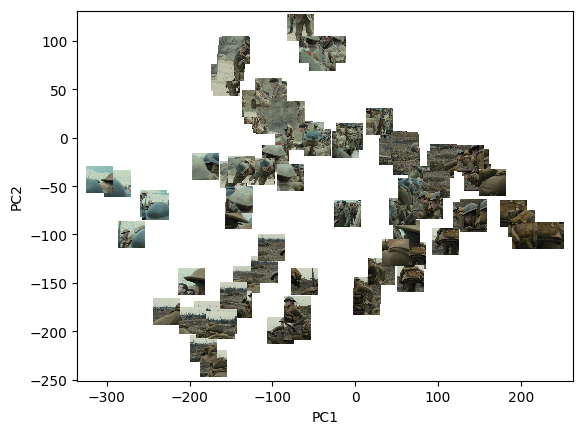

In [38]:
fig, ax = plt.subplots()

# scatter points (optional, for reference)
dims = (0,1)
ax.scatter(pts[:, dims[0]], pts[:, dims[1]])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

# overlay images
for i in range(pts.shape[0]):
    # ensure image is in (H, W, C) and in [0,1] or [0,255]
    x = pts[i, dims[0]]
    y = pts[i, dims[1]]
    c = chunk[i, :].detach().cpu().numpy()
    # m = np.abs(c).max()
    # c_min, c_max = c.min(), c.max()
    # img = (c - c_min) / (c_max - c_min + 1e-8)
    # img = c.transpose(1,2,0)
    image = OffsetImage(c, zoom=0.05, alpha=1)

    ab = AnnotationBbox(image, (x, y), frameon=False)
    ax.add_artist(ab)
plt.show()

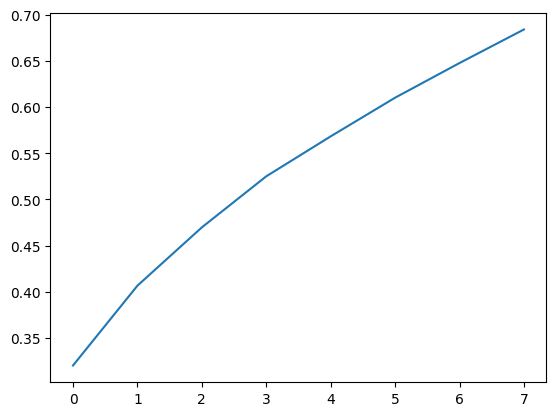

In [39]:
plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))

In [104]:
def get_layer_output_shape(feature_extractor, layer_name, imsize=224):
    with torch.no_grad():
        in_proxy = torch.randn(1, 3, imsize, imsize).to(device)
        tmp_shape = feature_extractor(in_proxy)[layer_name].shape[1:]
    return tmp_shape
# EOF 

get_layer_output_shape(feature_extractor, layers[0], imsize=384)

torch.Size([577, 1024])

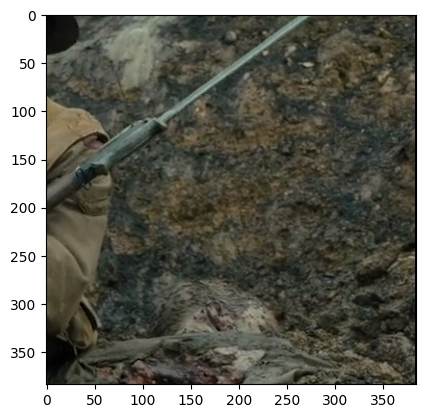

In [92]:
plt.imshow(chunk[0,:].reshape(3, 384, 384, order='F').transpose(1,2,0))

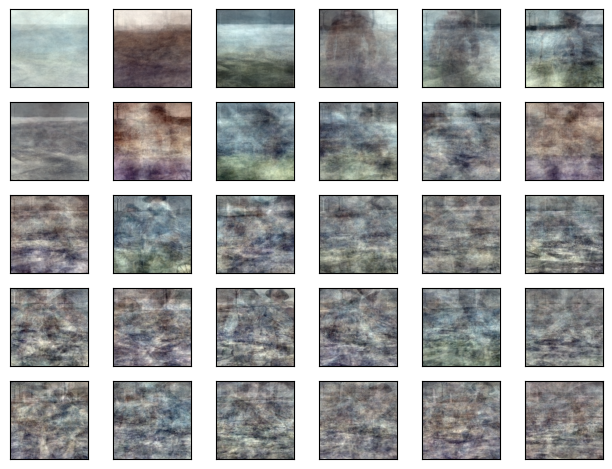

In [97]:
components = ipca_obj.components_
fig, axes = plt.subplots(5, 6)
axes = axes.ravel()
for i, ax in zip(range(cfg.n_components), axes):
    c = components[i, :]    
    c = c.reshape(3, cfg.sq_size, cfg.sq_size, order='F').transpose(1,2,0)
    m = np.abs(c).max()
    c = (c + m) / (2 * m)
    ax.imshow(c)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

In [46]:
3*np.sum(frames_per_run)/frames_step

np.float64(36619.2)

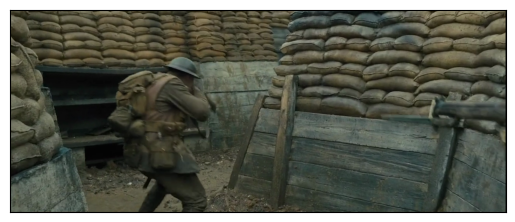

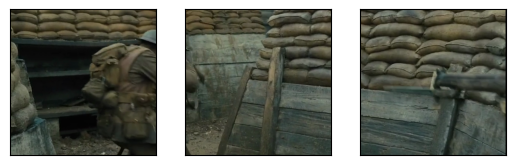

In [ ]:

try:
    for frame in v:
    # frame = v[1]
        h, w, c = frame.shape

        sq_size = 384
        d = (w - 3 * sq_size) // 4
        cy = h // 2
        cx1 = 2*d + sq_size//2
        cx2 = cx1 + d + sq_size
        cx3 = cx2 + d + sq_size
        cxs = [cx1, cx2, cx3]
        ps = []
        for cx in cxs:
            ps.append(extract_square_patch(frame, cx, cy, sq_size))
        plt.imshow(frame)
        plt.xticks([])
        plt.yticks([])
        fig, axes =plt.subplots(1, len(ps))
        for idx, ax in enumerate(axes):
            ax.imshow(ps[idx])
            ax.set_xticks([])
            ax.set_yticks([])
        plt.show()
        clear_output(wait=True)
        time.sleep(.5)
except KeyboardInterrupt:
    pass        

In [89]:
while True:
    np.random.shuffle(batch_starts)
    mask = batch_starts[:10] < min_frames -batch_size
    if np.all(mask):
        break
    else:
        print(1)

1


In [13]:
def ipca_videos(paths, rank, layer_name, model_name, model, n_components, video_type, batches_to_proc, batch_sizes, fn_list, long_vids,  device, vid_duration_lim, new_h=224, new_w=224):
    save_name = (f"{video_type}_{model_name}_{layer_name}_ipca_{n_components}_PCs.pkl")
    path = os.path.join(f"{paths["livingstone_lab"]}/tiziano/models", save_name)
    if os.path.exists(path):
        print_wise(f"{path} already exists")
    else:
        print_wise(f"Fitting PCA for layer: {layer_name}", rank=rank)
        frames_batch = []
        feature_extractor = create_feature_extractor(
            model, return_nodes=[layer_name]
        ).to(device)
        tmp_shape = get_layer_output_shape(feature_extractor, layer_name)
        n_features = np.prod(tmp_shape)  # [C, H, W] -> C*H*W
        n_components_layer = min(n_features, n_components)  # Limit to number of features
        ipca = IncrementalPCA(n_components=n_components_layer, batch_size=batch_sizes[0])
        curr_video_idx = 0
        for idx, curr_batch_size in enumerate(batch_sizes):

            print_wise(f"starting batch {idx}", rank=rank)
            frames_batch, curr_video_idx = concatenate_frames_batch(paths, rank, fn_list, frames_batch, curr_video_idx, idx, batches_to_proc, batch_sizes, new_h, new_w, long_vids, vid_duration_lim)
            frames_batch = shuffle_frames(frames_batch)
            inputs = frames_batch[:curr_batch_size, :, :, :]
            inputs = torch.from_numpy(inputs).float().to(device)
            inputs = inputs.permute(0, 3, 1, 2)
            frames_batch = frames_batch[curr_batch_size:, :, :, :]
            with torch.no_grad():
                feats = feature_extractor(inputs)[layer_name]
                print_wise(f"features shape: {feats.shape}", rank=rank)
                feats = feats.reshape(feats.size(0), -1).cpu().numpy()
            ipca.partial_fit(feats)
            # end with torch.no_grad():
        
        joblib.dump(ipca, path) 
        print_wise(f"Saved PCA for {layer_name} at {path}", rank=rank)


In [ ]:
def concatenate_frames_batch(paths, rank, fn_list, frames_batch, curr_video_idx, curr_batch_idx, batches_to_proc_togeth, batch_sizes, new_h, new_w, long_vids, vid_duration_lim=20, normalize=True):
    n_batches = len(batch_sizes)
    idx_tot = [curr_batch_idx + i for i in range(batches_to_proc_togeth) if curr_batch_idx + i < n_batches] # takes the next $batches_to_proc frames filtering for out of range indices 
    curr_tot_batch_size = np.sum(batch_sizes[idx_tot])
    cumulative_frames_sum = 0
    if is_empty(frames_batch):
        frames_batch = [] # otherwise we have arrays of inconsistent size to concatenate
    else:
        cumulative_frames_sum += frames_batch.shape[0]
        frames_batch = [frames_batch] # makes it a list with all the frames remained from the previous batch (ideally we read 3 batches and shuffle)
    # end if frames_batch:
    while cumulative_frames_sum < curr_tot_batch_size:
        fn = fn_list[curr_video_idx]
        if long_vids[curr_video_idx]: # if the video is marked as long
            video = read_video(paths, rank, fn, vid_duration=vid_duration_lim) # if the video is too long, we just process the beginning (vid_duration_lim is in sec)
        else:
            video = read_video(paths, rank, fn, vid_duration=0)
        # end if long_vids[progression]: 
        video = resize_video_array(video, new_h, new_w, normalize=False)
        curr_video_idx += 1
        curr_frames_n = video.shape[0] 
        cumulative_frames_sum += curr_frames_n
        frames_batch.append(video)
    # end while cumulative_frames_sum < curr_tot_batch_size:
    frames_batch = np.concatenate(frames_batch, axis=0)
    return frames_batch, curr_video_idx
# EOF
